# Clustering without dimensionality reduction on sampled data using different sampling methods

In [2]:
import pandas as pd
import matplotlib.pyplot as plt
import gsw
import numpy as np
from mpl_toolkits.basemap import Basemap
import plotly.graph_objs as go
from collections import defaultdict

In [3]:
# Get data into dataframe
df = pd.read_csv('../../../WMA_fractions_v2.csv', skiprows=1)

# Preprocess data to only have temperature, salinity and dissolved oxygen
df_ST = df.copy()
df_ST = df_ST[['Conservative_Temperature_[deg_C]', 'Absolute_Salinity_[PSU]', 'Dissolved_Oxygen_[micro_mol_per_kg]', 'Depth_[m]', 'Latitude_[deg_N]', 'Longitude_[deg_E]','Datetime_[UTC]']]
df_ST['year'] = pd.to_datetime(df_ST['Datetime_[UTC]']).dt.year
df_ST['month'] = pd.to_datetime(df_ST['Datetime_[UTC]']).dt.month
df_ST = df_ST[['Conservative_Temperature_[deg_C]', 'Absolute_Salinity_[PSU]', 'Dissolved_Oxygen_[micro_mol_per_kg]', 'Depth_[m]', 'Latitude_[deg_N]', 'Longitude_[deg_E]','year', 'month']]

In [4]:
# Break into two parts (1980-2000 and 2000-2023)
df_80_00 = df_ST[(df_ST['year'] >= 1980) & (df_ST['year'] < 2000)]
df_00_23 = df_ST[(df_ST['year'] >= 2000) & (df_ST['year'] < 2023)]

## Method 9 - min bins, polar stereo, geo and depth bins, 20 year separation

In [5]:
#min bins
flag = True

In [6]:
# Sample bins of bins (geographical and depth bins) in projection space
def sample_bins_of_bins_proj(df, n_x_bins=100, n_y_bins=100, n_depth_bins=5, projection='npstere', min_flag=True):
    # Define minimum latitude for projection
    lat_min = df['Latitude_[deg_N]'].min()

    # Convert lat/lon → x/y (projection coordinates in meters)
    lon_vals = df['Longitude_[deg_E]'].values
    lat_vals = df['Latitude_[deg_N]'].values
    x_vals, y_vals = Basemap(projection=projection, boundinglat=lat_min, lon_0=0, resolution='l')(lon_vals, lat_vals)

    x_min, x_max = x_vals.min(), x_vals.max()
    y_min, y_max = y_vals.min(), y_vals.max()

    # xy bins in projection space
    x_bins = np.linspace(x_min, x_max, n_x_bins + 1)
    y_bins = np.linspace(y_min, y_max, n_y_bins + 1)

    # depth bins in original depth space
    depth_bins = np.linspace(df['Depth_[m]'].min(), df['Depth_[m]'].max(), n_depth_bins + 1)

    # Assign each point to a bin
    df['x_bin'] = pd.cut(x_vals, bins=x_bins, labels=False, include_lowest=True)
    df['y_bin'] = pd.cut(y_vals, bins=y_bins, labels=False, include_lowest=True)  
    df['depth_bin'] = pd.cut(df['Depth_[m]'], bins=depth_bins, labels=False, include_lowest=True)
    
    # Find bin with least data points and sample that many points from each bin
    if min_flag:
        min_count = df.groupby(['x_bin', 'y_bin', 'depth_bin']).size().min()
        sampled_df = df.groupby(['x_bin', 'y_bin', 'depth_bin']).apply(lambda x: x.sample(min_count, random_state=22)).reset_index(drop=True)
    else:
        avg_count = df.groupby(['x_bin', 'y_bin', 'depth_bin']).size().mean().round().astype(int)
        sampled_df = (df.groupby(['x_bin', 'y_bin', 'depth_bin'], group_keys=False).apply(lambda g: g.sample(n=min(len(g), avg_count), random_state=22)).reset_index(drop=True))
    return sampled_df

In [7]:
df_sampled_0 = sample_bins_of_bins_proj(df_80_00, projection='npstere', min_flag=flag)
df_sampled_1 = sample_bins_of_bins_proj(df_00_23, projection='npstere', min_flag=flag)
df_sampled = pd.concat([df_sampled_0, df_sampled_1], ignore_index=True)

/var/folders/v0/0lp_zzrd33sgh7y2jyh9zzdm0000gn/T/ipykernel_35380/3865529425.py:22: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df['x_bin'] = pd.cut(x_vals, bins=x_bins, labels=False, include_lowest=True)
/var/folders/v0/0lp_zzrd33sgh7y2jyh9zzdm0000gn/T/ipykernel_35380/3865529425.py:23: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df['y_bin'] = pd.cut(y_vals, bins=y_bins, labels=False, include_lowest=True)
/var/folders/v0/0lp_zzrd33sgh7y2jyh9zzdm0000gn/T/ipykernel_35380/3865529425.py:24: SettingWithCopyWa

In [54]:
def profileNo_vs_xy_bins(
    df: pd.DataFrame,
    n_x_bins: int = 100,
    n_y_bins: int = 100,
    show_threshold: bool = False,
    threshold_quantile: float = 0.95,
    projection: str = 'npstere'
) -> None:
    """
    Plot the number of profiles in each bin using polar stereographic projection.
    Args:
        df (pd.DataFrame): The dataset to plot.
        n_x_bins (int): Number of bins in the x direction. Defaults to 100.
        n_y_bins (int): Number of bins in the y direction. Defaults to 100.
        show_threshold (bool, optional): Whether to show the threshold marker. Defaults to False.
        threshold_quantile (float, optional): The quantile value for threshold calculation. Defaults to 0.95.
        projection (str, optional): Basemap projection string. Defaults to 'npstere'.
    Returns:
        None
    """
    # Set up the polar stereographic projection
    lat_min = df['Latitude_[deg_N]'].min()
    m = Basemap(projection=projection, boundinglat=lat_min, lon_0=0, resolution='l')

    # Reproject lat/lon to x/y (projection coordinates in metres)
    lon_vals = df['Longitude_[deg_E]'].values
    lat_vals = df['Latitude_[deg_N]'].values
    x_vals, y_vals = m(lon_vals, lat_vals)

    # Define XY bin edges in projected space
    x_min, x_max = x_vals.min(), x_vals.max()
    y_min, y_max = y_vals.min(), y_vals.max()
    x_bins = np.linspace(x_min, x_max, n_x_bins + 1)
    y_bins = np.linspace(y_min, y_max, n_y_bins + 1)

    # Digitize points into bins
    x_idx = np.digitize(x_vals, x_bins) - 1
    y_idx = np.digitize(y_vals, y_bins) - 1

    # Count number of profiles per bin
    H = np.zeros((n_x_bins, n_y_bins), dtype=int)
    for i in range(len(x_vals)):
        xi, yi = x_idx[i], y_idx[i]
        if 0 <= xi < n_x_bins and 0 <= yi < n_y_bins:
            H[xi, yi] += 1

    # Flatten to get non-zero bin counts (matching original behaviour of only counting occupied bins)
    g_len = H[H > 0].flatten().tolist()
    g_len_sorted = sorted(g_len)

    # Threshold / transition point detection
    transition_point = None
    if len(g_len_sorted) > 1:
        g_len_diff = np.diff(g_len_sorted)
        threshold = np.quantile(g_len_diff, threshold_quantile)
        for i in range(1, len(g_len_sorted)):
            if g_len_sorted[i] - g_len_sorted[i - 1] > threshold:
                transition_point = i - 1
                break

    # Build Plotly traces
    trace = go.Scatter(
        x=list(range(len(g_len_sorted))),
        y=g_len_sorted
    )

    if show_threshold and transition_point is not None:
        red_dot = go.Scatter(
            x=[transition_point],
            y=[g_len_sorted[transition_point]],
            mode='markers',
            marker=dict(color='red', size=10)
        )
        fig_data = [trace, red_dot]
    else:
        fig_data = [trace]

    layout = go.Layout(
        xaxis=dict(title='Bin No.'),
        yaxis=dict(title='Number of points per bin')
    )
    fig = go.Figure(data=fig_data, layout=layout)
    fig.show()

    return g_len_sorted[transition_point]

In [55]:
_ = profileNo_vs_xy_bins(df_ST, n_x_bins=100, n_y_bins=100, show_threshold=True, threshold_quantile=0.99, projection='npstere')

In [9]:
profileNo_vs_xy_bins(df_sampled, n_x_bins=100, n_y_bins=100, show_threshold=False, threshold_quantile=0.99, projection='npstere')

In [10]:
import random
from sklearn.mixture import GaussianMixture

In [11]:
# Define random seed for reproducibility
seed = 22
random.seed(seed)

In [12]:
features = ['Conservative_Temperature_[deg_C]', 'Absolute_Salinity_[PSU]']

In [16]:
# Four clusters for comparison of methods
n_clusters = 4

In [13]:
gmm = GaussianMixture(
    n_components=n_clusters,          # number of clusters
    covariance_type='full',  # full cov matrix has more flexibility
    random_state=seed)

labels = gmm.fit_predict(df_sampled[features])

In [14]:
df_sampled['gmm_label_4'] = labels

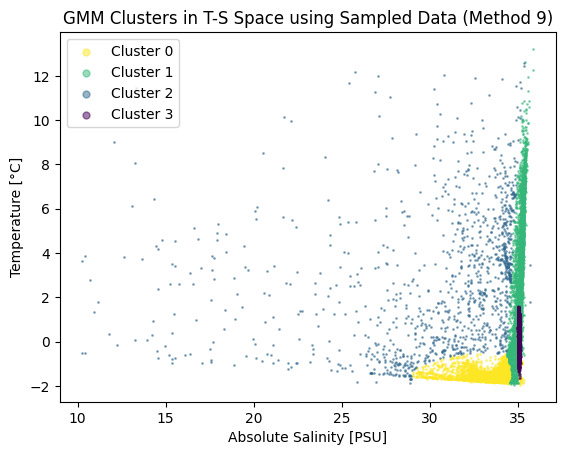

In [18]:
plt.figure()

# Discrete Viridis colours full range (reversed)
colors = plt.cm.viridis_r(np.linspace(0, 1, n_clusters))

for i in range(n_clusters):
    mask = df_sampled['gmm_label_4'] == i
    plt.scatter(
        df_sampled.loc[mask, 'Absolute_Salinity_[PSU]'],
        df_sampled.loc[mask, 'Conservative_Temperature_[deg_C]'],
        s=1,
        alpha=0.5,
        color=colors[i],
        label=f'Cluster {i}')

plt.xlabel("Absolute Salinity [PSU]")
plt.ylabel("Temperature [°C]")
plt.title("GMM Clusters in T-S Space using Sampled Data (Method 9)")
plt.legend(loc='upper left', markerscale=5)
plt.show()

In [19]:
# Do BIC and AIC calculation for different number of clusters
bic_scores = []
n_components_range = range(1, 12)
for n_components in n_components_range:
    gmm = GaussianMixture(n_components=n_components, covariance_type='full', random_state=seed) # full cov matrix has more flexibility
    gmm.fit(df_sampled[features])
    bic_scores.append(gmm.bic(df_sampled[features]))

Text(0.5, 1.0, 'BIC Scores for GMM with Different Number of Components')

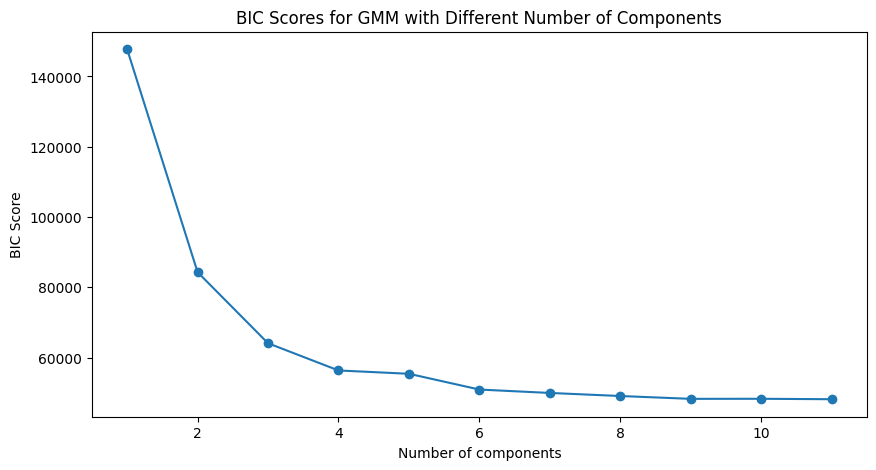

In [20]:
plt.figure(figsize=(10,5))
plt.plot(n_components_range, bic_scores, label='BIC', marker='o')
plt.xlabel('Number of components')
plt.ylabel('BIC Score')
plt.title('BIC Scores for GMM with Different Number of Components')

In [21]:
# Choice of optimal number of clusters based on BIC
optimal_n_components = 6

In [22]:
gmm = GaussianMixture(
    n_components=optimal_n_components,          # number of clusters
    covariance_type='full',  # full cov matrix has more flexibility
    random_state=seed)

labels = gmm.fit_predict(df_sampled[features])

In [23]:
df_sampled['gmm_label'] = labels

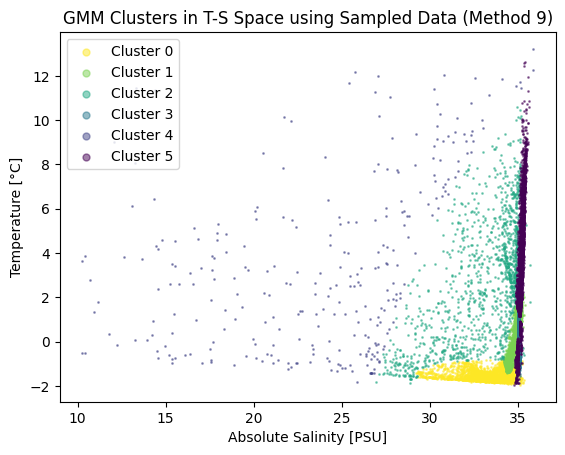

In [24]:
plt.figure()

# Discrete Viridis colours full range (reversed)
colors = plt.cm.viridis_r(np.linspace(0, 1, optimal_n_components))

for i in range(optimal_n_components):
    mask = df_sampled['gmm_label'] == i
    plt.scatter(
        df_sampled.loc[mask, 'Absolute_Salinity_[PSU]'],
        df_sampled.loc[mask, 'Conservative_Temperature_[deg_C]'],
        s=1,
        alpha=0.5,
        color=colors[i],
        label=f'Cluster {i}')

plt.xlabel("Absolute Salinity [PSU]")
plt.ylabel("Temperature [°C]")
plt.title("GMM Clusters in T-S Space using Sampled Data (Method 9)")
plt.legend(loc='upper left', markerscale=5)
plt.show()

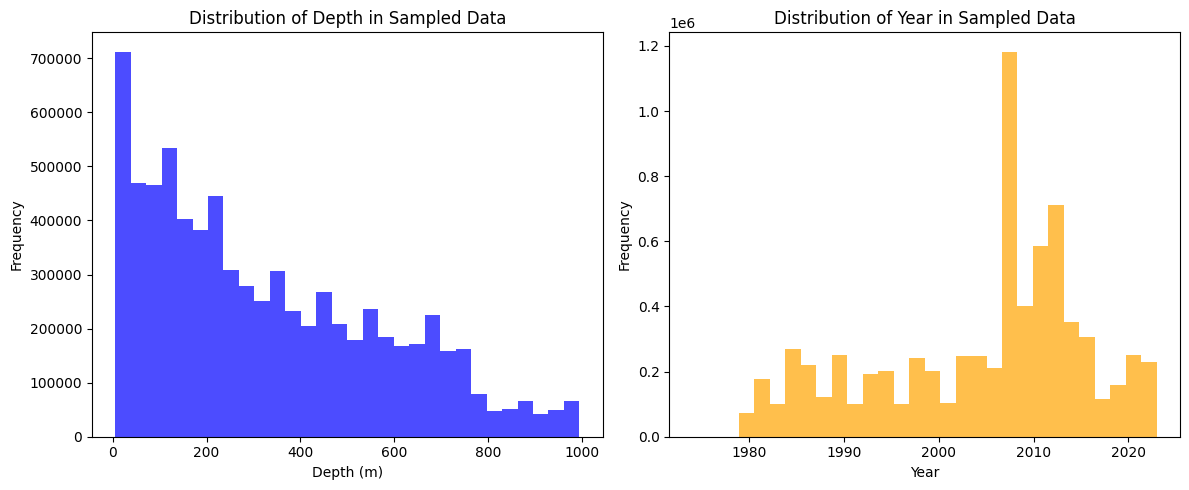

In [69]:
# Plot distribution of depth and temporal coverage
plt.figure(figsize=(12, 5))
plt.subplot(1, 2, 1)
plt.hist(df_sampled['Depth_[m]'], bins=30, edgecolor='black', alpha=0.7)
plt.xlabel('Depth (m)')
plt.ylabel('Frequency')
plt.title('Distribution of Depth in Sampled Data')
plt.subplot(1, 2, 2)
plt.hist(df_sampled['year'], bins=30, edgecolor='black', alpha=0.7)
plt.xlabel('Year')
plt.ylabel('Frequency')
plt.title('Distribution of Year in Sampled Data')
plt.tight_layout()
plt.show()

In [70]:
def plot_heatmap_npts_xy(ds_cleaned, n_x_bins=100, n_y_bins=100, bin_max=None, projection='npstere', projection_name='Polar Stereographic'):
    lat_min = ds_cleaned['Latitude_[deg_N]'].min()
    resolution = 'l'

    fig = plt.figure(figsize=(8, 8), dpi=300)
    m = Basemap(projection=projection, boundinglat=lat_min, lon_0=0, resolution=resolution)

    # Convert lat/lon → x/y (projection coordinates in meters)
    lon_vals = ds_cleaned['Longitude_[deg_E]'].values
    lat_vals = ds_cleaned['Latitude_[deg_N]'].values

    # Reproject lat/lon to x/y
    x_vals, y_vals = m(lon_vals, lat_vals)

    # Define XY bin edges
    x_min, x_max = x_vals.min(), x_vals.max()
    y_min, y_max = y_vals.min(), y_vals.max()

    x_bins = np.linspace(x_min, x_max, n_x_bins + 1)
    y_bins = np.linspace(y_min, y_max, n_y_bins + 1)

    # Grid to store max depth
    H = np.zeros((n_x_bins, n_y_bins))

    # Digitize into bins
    x_idx = np.digitize(x_vals, x_bins) - 1
    y_idx = np.digitize(y_vals, y_bins) - 1

    # Count number of points in each bin
    for i in range(len(x_vals)):
        xi, yi = x_idx[i], y_idx[i]
        if 0 <= xi < n_x_bins and 0 <= yi < n_y_bins:
            H[xi, yi] += 1

    # Create meshgrid for plotting
    X, Y = np.meshgrid(x_bins, y_bins)

    # Colormap
    cmap = plt.get_cmap('Wistia').copy()
    cmap.set_under(color='white', alpha=1.0)
    cmap.set_over(color='white', alpha=1.0)

    if bin_max is None:
        bin_max = H.max()

    # Plot heatmap
    m.pcolormesh(X, Y, H.T, cmap=cmap, vmin=1, vmax=bin_max)

    # Draw bin grid (in xy space)
    for xb in x_bins:
        plt.plot([xb]*len(y_bins), y_bins, color='grey', linewidth=0.05, zorder=3)
    for yb in y_bins:
        plt.plot(x_bins, [yb]*len(x_bins), color='grey', linewidth=0.05, zorder=3)

    # Plot coastlines on top
    m.drawcoastlines()
    m.fillcontinents(color='lightgrey', lake_color='lightblue')

    cbar = m.colorbar(location='bottom', pad="5%")
    cbar.set_label('Number of points per bin')

    plt.xticks([])
    plt.yticks([])
    plt.title('Number of Points per Bin in '+ f'({projection_name} Projection)')

    plt.show()

In [ ]:
plot_heatmap_npts_xy(df_sampled, n_x_bins=100, n_y_bins=100, projection='npstere', projection_name='Polar Stereographic')

# Method 21 - polar stereographic projection, geo and depth bins, 20 year separation, average bin cap

In [27]:
#avg bins
flag = False

In [28]:
df_sampled_0 = sample_bins_of_bins_proj(df_80_00, projection='npstere', min_flag=flag)
df_sampled_1 = sample_bins_of_bins_proj(df_00_23, projection='npstere', min_flag=flag)
df_sampled = pd.concat([df_sampled_0, df_sampled_1], ignore_index=True)

/var/folders/v0/0lp_zzrd33sgh7y2jyh9zzdm0000gn/T/ipykernel_35380/3865529425.py:22: SettingWithCopyWarning:


A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy

/var/folders/v0/0lp_zzrd33sgh7y2jyh9zzdm0000gn/T/ipykernel_35380/3865529425.py:23: SettingWithCopyWarning:


A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy

/var/folders/v0/0lp_zzrd33sgh7y2jyh9zzdm0000gn/T/ipykernel_35380/3865529425.py:24: SettingWithCopyWarning:


A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in th

In [29]:
profileNo_vs_xy_bins(df_sampled, n_x_bins=100, n_y_bins=100, show_threshold=False, threshold_quantile=0.99, projection='npstere')

# Four clusters for comparison of methods

In [30]:
# Four clusters for comparison of methods
n_clusters = 4

In [31]:
gmm = GaussianMixture(
    n_components=n_clusters,          # number of clusters
    covariance_type='full',  # full cov matrix has more flexibility
    random_state=seed)

labels = gmm.fit_predict(df_sampled[features])

In [32]:
df_sampled['gmm_label_4'] = labels

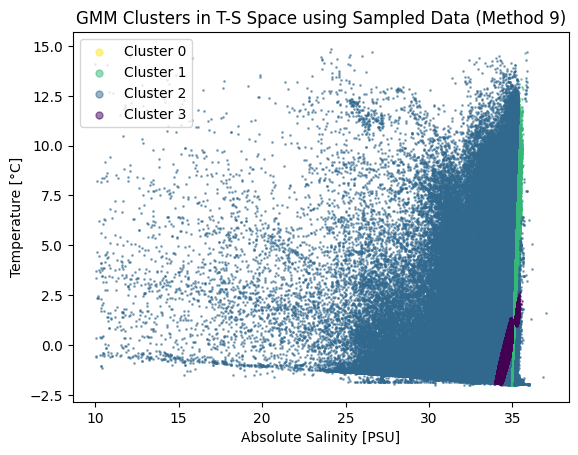

In [33]:
plt.figure()

# Discrete Viridis colours full range (reversed)
colors = plt.cm.viridis_r(np.linspace(0, 1, n_clusters))

for i in range(n_clusters):
    mask = df_sampled['gmm_label_4'] == i
    plt.scatter(
        df_sampled.loc[mask, 'Absolute_Salinity_[PSU]'],
        df_sampled.loc[mask, 'Conservative_Temperature_[deg_C]'],
        s=1,
        alpha=0.5,
        color=colors[i],
        label=f'Cluster {i}')

plt.xlabel("Absolute Salinity [PSU]")
plt.ylabel("Temperature [°C]")
plt.title("GMM Clusters in T-S Space using Sampled Data (Method 21)")
plt.legend(loc='upper left', markerscale=5)
plt.show()

In [30]:
# Define random seed for reproducibility
seed = 22
random.seed(seed)

In [31]:
# Do BIC and AIC calculation for different number of clusters
bic_scores = []
n_components_range = range(1, 12)
for n_components in n_components_range:
    gmm = GaussianMixture(n_components=n_components, covariance_type='full', random_state=seed) # full cov matrix has more flexibility
    gmm.fit(df_sampled[features])
    bic_scores.append(gmm.bic(df_sampled[features]))

Text(0.5, 1.0, 'BIC Scores for GMM with Different Number of Components')

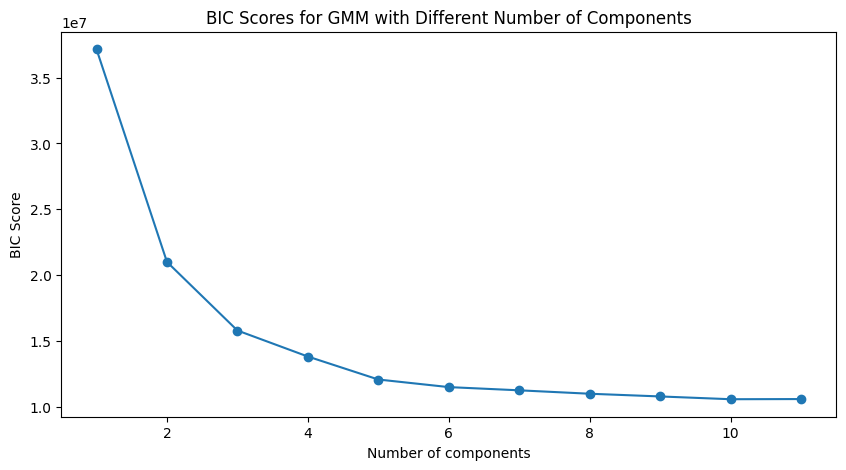

In [32]:
plt.figure(figsize=(10,5))
plt.plot(n_components_range, bic_scores, label='BIC', marker='o')
plt.xlabel('Number of components')
plt.ylabel('BIC Score')
plt.title('BIC Scores for GMM with Different Number of Components')

In [34]:
# Choice of optimal number of clusters based on BIC
optimal_n_components = 5

In [35]:
gmm = GaussianMixture(
    n_components=optimal_n_components,          # number of clusters
    covariance_type='full',  # full cov matrix has more flexibility
    random_state=seed)

labels = gmm.fit_predict(df_sampled[features])

In [36]:
df_sampled['gmm_label'] = labels

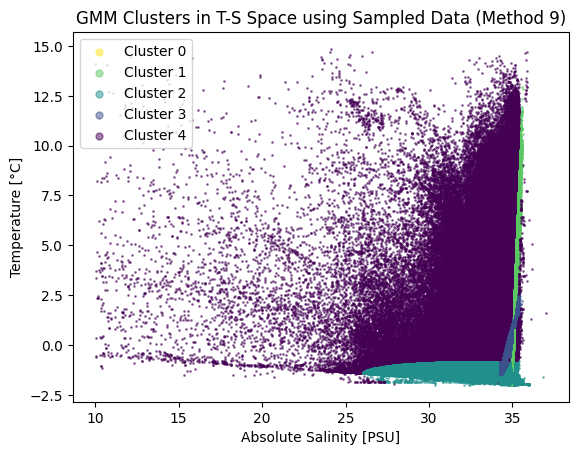

In [37]:
plt.figure()

# Discrete Viridis colours full range (reversed)
colors = plt.cm.viridis_r(np.linspace(0, 1, optimal_n_components))

for i in range(optimal_n_components):
    mask = df_sampled['gmm_label'] == i
    plt.scatter(
        df_sampled.loc[mask, 'Absolute_Salinity_[PSU]'],
        df_sampled.loc[mask, 'Conservative_Temperature_[deg_C]'],
        s=1,
        alpha=0.5,
        color=colors[i],
        label=f'Cluster {i}')

plt.xlabel("Absolute Salinity [PSU]")
plt.ylabel("Temperature [°C]")
plt.title("GMM Clusters in T-S Space using Sampled Data (Method 21)")
plt.legend(loc='upper left', markerscale=5)
plt.show()

In [ ]:
# Plot distribution of depth and temporal coverage
plt.figure(figsize=(12, 5))
plt.subplot(1, 2, 1)
plt.hist(df_sampled['Depth_[m]'], bins=30, edgecolor='black', alpha=0.7)
plt.xlabel('Depth (m)')
plt.ylabel('Frequency')
plt.title('Distribution of Depth in Sampled Data')
plt.subplot(1, 2, 2)
plt.hist(df_sampled['year'], bins=30, edgecolor='black', alpha=0.7)
plt.xlabel('Year')
plt.ylabel('Frequency')
plt.title('Distribution of Year in Sampled Data')
plt.tight_layout()
plt.show()

In [ ]:
plot_heatmap_npts_xy(df_sampled, n_x_bins=100, n_y_bins=100, projection='npstere', projection_name='Polar Stereographic')

# Method 26 - lat-lon bins, 95th percentile cap random sampling

In [36]:
def profileNo_vs_latlon_bins(
    df: pd.DataFrame,
    lat_step: float,
    lon_step: float,
    show_threshold: bool = False,
    threshold_quantile: float = 0.95
) -> float | None:
    
    # === Identical bin construction to sample_cap_bins / plot_heatmap_npts ===
    lon_min, lon_max = -180, 180
    lat_min, lat_max = 55, 90

    lon_bins = np.arange(lon_min, lon_max + lon_step, lon_step)

    sin_step = np.sin(np.radians(lat_step)) - np.sin(np.radians(0))
    sin_min = np.sin(np.radians(lat_min))
    sin_max = np.sin(np.radians(lat_max))
    sin_bins = np.arange(sin_min, sin_max + sin_step, sin_step)
    lat_bins = np.degrees(np.arcsin(np.clip(sin_bins, -1, 1)))

    n_lon_bins = len(lon_bins) - 1
    n_lat_bins = len(lat_bins) - 1
    # =========================================================================

    lon_vals = df['Longitude_[deg_E]'].values
    lat_vals = df['Latitude_[deg_N]'].values

    lon_idx = np.clip(np.digitize(lon_vals, lon_bins) - 1, 0, n_lon_bins - 1)
    lat_idx = np.clip(np.digitize(lat_vals, lat_bins) - 1, 0, n_lat_bins - 1)

    # Count per bin
    from collections import defaultdict
    bin_counts = defaultdict(int)
    for i in range(len(lon_vals)):
        bin_counts[(lon_idx[i], lat_idx[i])] += 1

    g_len = list(bin_counts.values())
    g_len_sorted = sorted(g_len)

    # Threshold detection
    transition_point = None
    if len(g_len_sorted) > 1:
        g_len_diff = np.diff(g_len_sorted)
        threshold = np.quantile(g_len_diff, threshold_quantile)
        for i in range(1, len(g_len_sorted)):
            if g_len_sorted[i] - g_len_sorted[i - 1] > threshold:
                transition_point = i - 1
                break

    trace = go.Scatter(
        x=list(range(len(g_len_sorted))),
        y=g_len_sorted
    )

    if show_threshold and transition_point is not None:
        red_dot = go.Scatter(
            x=[transition_point],
            y=[g_len_sorted[transition_point]],
            mode='markers',
            marker=dict(color='red', size=10)
        )
        fig_data = [trace, red_dot]
    else:
        fig_data = [trace]

    layout = go.Layout(
        xaxis=dict(title='Bin No.'),
        yaxis=dict(title='Number of points per bin')
    )
    fig = go.Figure(data=fig_data, layout=layout)
    fig.show()

    return g_len_sorted[transition_point]

In [37]:
threshold = profileNo_vs_latlon_bins(df_ST, lat_step=2, lon_step=2, show_threshold=True, threshold_quantile=0.95)

In [38]:
print(threshold)

37672


In [39]:
def sample_cap_bins(df, thresh, lon_step=5, lat_step=5):
    lon_min, lon_max = -180, 180
    lat_min, lat_max = 55, 90

    lon_bins = np.arange(lon_min, lon_max + lon_step, lon_step)

    sin_step = np.sin(np.radians(lat_step)) - np.sin(np.radians(0))
    sin_min = np.sin(np.radians(lat_min))
    sin_max = np.sin(np.radians(lat_max))
    sin_bins = np.arange(sin_min, sin_max + sin_step, sin_step)
    lat_bins = np.degrees(np.arcsin(np.clip(sin_bins, -1, 1)))

    n_lon_bins = len(lon_bins) - 1
    n_lat_bins = len(lat_bins) - 1

    lon_vals = df['Longitude_[deg_E]'].values
    lat_vals = df['Latitude_[deg_N]'].values

    lon_idx = np.clip(np.digitize(lon_vals, lon_bins) - 1, 0, n_lon_bins - 1)
    lat_idx = np.clip(np.digitize(lat_vals, lat_bins) - 1, 0, n_lat_bins - 1)

    bin_members = defaultdict(list)
    for i in range(len(lon_vals)):
        bin_members[(lon_idx[i], lat_idx[i])].append(i)

    sampled_indices = []
    for (xi, yi), members in bin_members.items():
        if len(members) > thresh:
            sampled_indices.extend(
                np.random.choice(members, size=thresh, replace=False).tolist()
            )
        else:
            sampled_indices.extend(members)

    return df.iloc[sampled_indices].copy()

In [40]:
df_sampled = sample_cap_bins(df_ST, thresh=threshold, lon_step=2, lat_step=2)

In [52]:
_ = profileNo_vs_latlon_bins(df_sampled, lat_step=2, lon_step=2, show_threshold=False, threshold_quantile=0.95)

# Four clusters for comparison of methods

In [41]:
n_clusters = 4

In [42]:
gmm = GaussianMixture(
    n_components=n_clusters,          # number of clusters
    covariance_type='full',  # full cov matrix has more flexibility
    random_state=seed)

labels = gmm.fit_predict(df_sampled[features])

In [43]:
df_sampled['gmm_label_4'] = labels

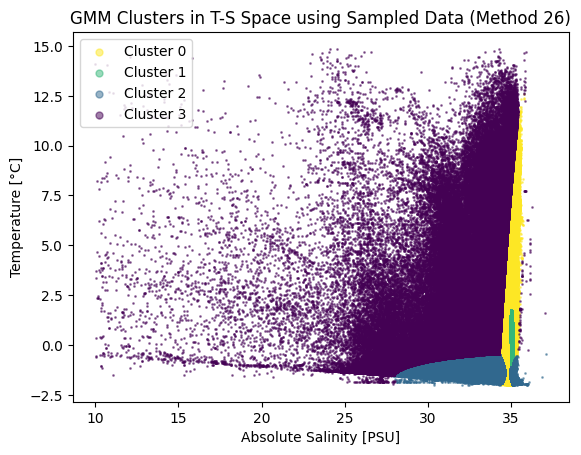

In [44]:
plt.figure()

# Discrete Viridis colours full range (reversed)
colors = plt.cm.viridis_r(np.linspace(0, 1, n_clusters))

for i in range(n_clusters):
    mask = df_sampled['gmm_label_4'] == i
    plt.scatter(
        df_sampled.loc[mask, 'Absolute_Salinity_[PSU]'],
        df_sampled.loc[mask, 'Conservative_Temperature_[deg_C]'],
        s=1,
        alpha=0.5,
        color=colors[i],
        label=f'Cluster {i}')

plt.xlabel("Absolute Salinity [PSU]")
plt.ylabel("Temperature [°C]")
plt.title("GMM Clusters in T-S Space using Sampled Data (Method 26)")
plt.legend(loc='upper left', markerscale=5)
plt.show()

In [53]:
# Define random seed for reproducibility
seed = 22
random.seed(seed)

In [54]:
# Do BIC and AIC calculation for different number of clusters
bic_scores = []
n_components_range = range(1, 12)
for n_components in n_components_range:
    gmm = GaussianMixture(n_components=n_components, covariance_type='full', random_state=seed) # full cov matrix has more flexibility
    gmm.fit(df_sampled[features])
    bic_scores.append(gmm.bic(df_sampled[features]))

Text(0.5, 1.0, 'BIC Scores for GMM with Different Number of Components')

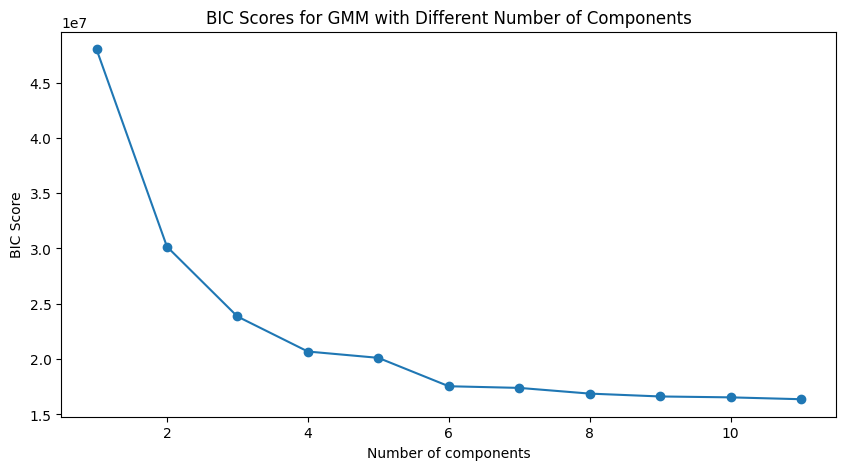

In [55]:
plt.figure(figsize=(10,5))
plt.plot(n_components_range, bic_scores, label='BIC', marker='o')
plt.xlabel('Number of components')
plt.ylabel('BIC Score')
plt.title('BIC Scores for GMM with Different Number of Components')

In [56]:
# Choice of optimal number of clusters based on BIC
optimal_n_components = 6

In [57]:
gmm = GaussianMixture(
    n_components=optimal_n_components,          # number of clusters
    covariance_type='full',  # full cov matrix has more flexibility
    random_state=seed)

labels = gmm.fit_predict(df_sampled[features])

In [58]:
df_sampled['gmm_label'] = labels

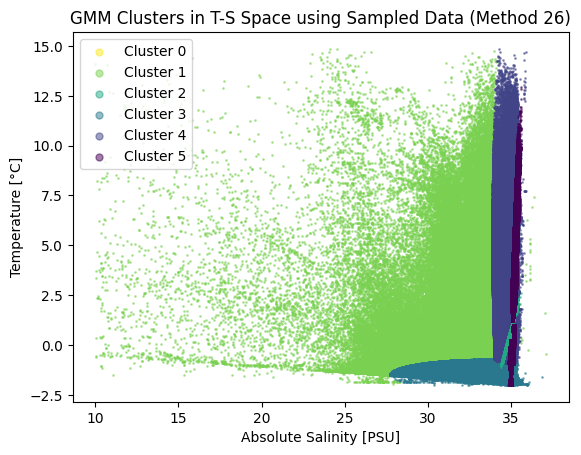

In [60]:
plt.figure()

# Discrete Viridis colours full range (reversed)
colors = plt.cm.viridis_r(np.linspace(0, 1, optimal_n_components))

for i in range(optimal_n_components):
    mask = df_sampled['gmm_label'] == i
    plt.scatter(
        df_sampled.loc[mask, 'Absolute_Salinity_[PSU]'],
        df_sampled.loc[mask, 'Conservative_Temperature_[deg_C]'],
        s=1,
        alpha=0.5,
        color=colors[i],
        label=f'Cluster {i}')

plt.xlabel("Absolute Salinity [PSU]")
plt.ylabel("Temperature [°C]")
plt.title("GMM Clusters in T-S Space using Sampled Data (Method 26)")
plt.legend(loc='upper left', markerscale=5)
plt.show()

In [ ]:
# Plot distribution of depth and temporal coverage
plt.figure(figsize=(12, 5))
plt.subplot(1, 2, 1)
plt.hist(df_sampled['Depth_[m]'], bins=30, edgecolor='black', alpha=0.7)
plt.xlabel('Depth (m)')
plt.ylabel('Frequency')
plt.title('Distribution of Depth in Sampled Data')
plt.subplot(1, 2, 2)
plt.hist(df_sampled['year'], bins=30, edgecolor='black', alpha=0.7)
plt.xlabel('Year')
plt.ylabel('Frequency')
plt.title('Distribution of Year in Sampled Data')
plt.tight_layout()
plt.show()

In [ ]:
def plot_heatmap_npts(ds_cleaned, lon_step=5, lat_step=5):
    lon_min, lon_max = -180, 180
    lat_min, lat_max = 55, 90
    resolution = 'l'

    # Longitude bins: uniform steps in degrees
    lon_bins = np.arange(lon_min, lon_max + lon_step, lon_step)

    # Equal-area latitude bins: uniform steps in sin(latitude)
    # Convert lat_step in degrees to an equivalent step in sin-space
    sin_step = np.sin(np.radians(lat_step)) - np.sin(np.radians(0))
    sin_min = np.sin(np.radians(lat_min))
    sin_max = np.sin(np.radians(lat_max))
    sin_bins = np.arange(sin_min, sin_max + sin_step, sin_step)
    lat_bins = np.degrees(np.arcsin(np.clip(sin_bins, -1, 1)))

    n_lon_bins = len(lon_bins) - 1
    n_lat_bins = len(lat_bins) - 1

    lon_vals = ds_cleaned['Longitude_[deg_E]'].values
    lat_vals = ds_cleaned['Latitude_[deg_N]'].values

    lon_idx = np.clip(np.digitize(lon_vals, lon_bins) - 1, 0, n_lon_bins - 1)
    lat_idx = np.clip(np.digitize(lat_vals, lat_bins) - 1, 0, n_lat_bins - 1)

    count = np.zeros((n_lon_bins, n_lat_bins), dtype=int)
    for i in range(len(lon_vals)):
        count[lon_idx[i], lat_idx[i]] += 1

    fig = plt.figure(figsize=(8, 8), dpi=300)
    m = Basemap(projection='npstere', boundinglat=lat_min, lon_0=0, resolution=resolution)
    m.drawcoastlines()
    m.fillcontinents(color='grey', lake_color='lightblue')

    for lat in lat_bins:
        lons = np.linspace(lon_min, lon_max, 500)
        x, y = m(lons, np.full_like(lons, lat))
        m.plot(x, y, color='grey', linewidth=0.05, zorder=3)

    for lon in lon_bins:
        lats = np.linspace(lat_min, lat_max, 500)
        x, y = m(np.full_like(lats, lon), lats)
        m.plot(x, y, color='grey', linewidth=0.05, zorder=3)

    X, Y = np.meshgrid(lon_bins, lat_bins)
    X_map, Y_map = m(X, Y)
    cmap = plt.get_cmap('Wistia').copy()
    cmap.set_under(color='white', alpha=1.0)
    cmap.set_over(color='white', alpha=1.0)
    m.pcolormesh(X_map, Y_map, count.T, cmap=cmap, vmin=1, vmax=None)

    m.drawcoastlines()
    m.fillcontinents(color='lightgrey', lake_color='lightblue')
    cbar = m.colorbar(location='bottom', pad="5%")
    cbar.set_label('Number of points in bin')
    plt.xticks([])
    plt.yticks([])
    plt.title(f'Number of Points per Bin ({lon_step}° lon x ~{lat_step}° lat equal-area bins)')
    plt.show()

In [ ]:
plot_heatmap_npts(df_sampled, lon_step=2, lat_step=2)

# Method 27 - lat-lon bins, 99th percentile cut off random sampling

In [45]:
threshold = profileNo_vs_latlon_bins(df_ST, lat_step=2, lon_step=2, show_threshold=True, threshold_quantile=0.99)

In [46]:
print(threshold)

99416


In [47]:
df_sampled = sample_cap_bins(df_ST, thresh=threshold, lon_step=2, lat_step=2)

In [64]:
_ = profileNo_vs_latlon_bins(df_sampled, lat_step=2, lon_step=2)

# Four clusters to compare methods

In [48]:
# Four clusters for comparison of methods
n_clusters = 4

In [49]:
gmm = GaussianMixture(
    n_components=n_clusters,          # number of clusters
    covariance_type='full',  # full cov matrix has more flexibility
    random_state=seed)

labels = gmm.fit_predict(df_sampled[features])

In [50]:
df_sampled['gmm_label_4'] = labels

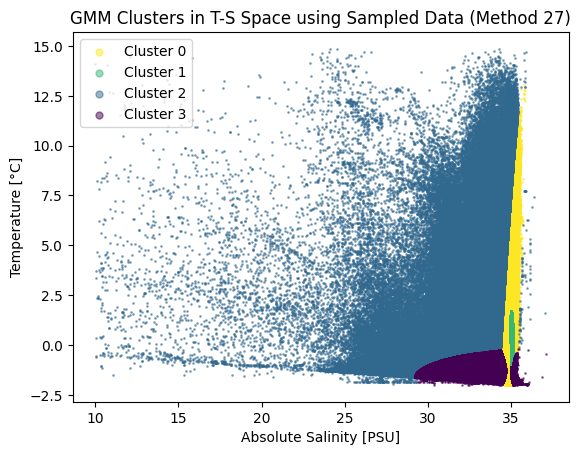

In [51]:
plt.figure()

# Discrete Viridis colours full range (reversed)
colors = plt.cm.viridis_r(np.linspace(0, 1, n_clusters))

for i in range(n_clusters):
    mask = df_sampled['gmm_label_4'] == i
    plt.scatter(
        df_sampled.loc[mask, 'Absolute_Salinity_[PSU]'],
        df_sampled.loc[mask, 'Conservative_Temperature_[deg_C]'],
        s=1,
        alpha=0.5,
        color=colors[i],
        label=f'Cluster {i}')

plt.xlabel("Absolute Salinity [PSU]")
plt.ylabel("Temperature [°C]")
plt.title("GMM Clusters in T-S Space using Sampled Data (Method 27)")
plt.legend(loc='upper left', markerscale=5)
plt.show()

In [65]:
# Define random seed for reproducibility
seed = 22
random.seed(seed)

In [66]:
# Do BIC and AIC calculation for different number of clusters
bic_scores = []
n_components_range = range(1, 12)
for n_components in n_components_range:
    gmm = GaussianMixture(n_components=n_components, covariance_type='full', random_state=seed) # full cov matrix has more flexibility
    gmm.fit(df_sampled[features])
    bic_scores.append(gmm.bic(df_sampled[features]))

Text(0.5, 1.0, 'BIC Scores for GMM with Different Number of Components')

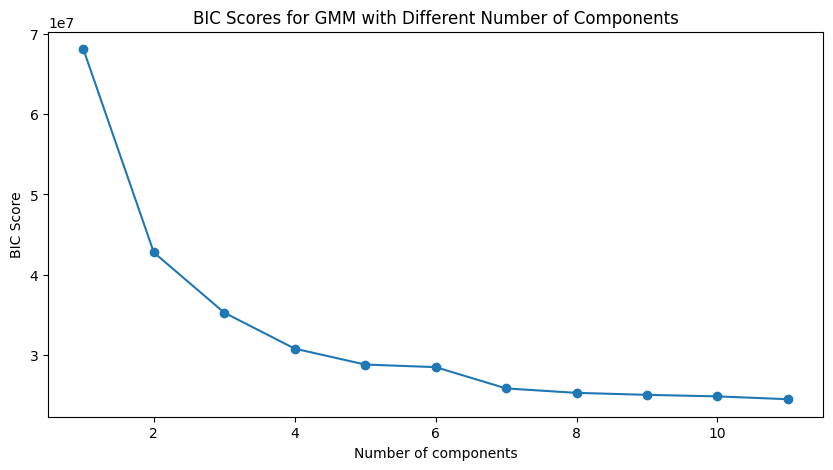

In [67]:
plt.figure(figsize=(10,5))
plt.plot(n_components_range, bic_scores, label='BIC', marker='o')
plt.xlabel('Number of components')
plt.ylabel('BIC Score')
plt.title('BIC Scores for GMM with Different Number of Components')

In [70]:
# Choice of optimal number of clusters based on BIC
optimal_n_components = 7

In [71]:
gmm = GaussianMixture(
    n_components=optimal_n_components,          # number of clusters
    covariance_type='full',  # full cov matrix has more flexibility
    random_state=seed)

labels = gmm.fit_predict(df_sampled[features])

In [72]:
df_sampled['gmm_label'] = labels

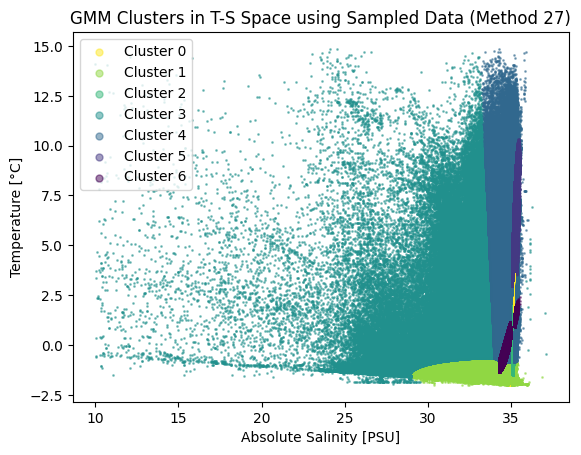

In [73]:
plt.figure()

# Discrete Viridis colours full range (reversed)
colors = plt.cm.viridis_r(np.linspace(0, 1, optimal_n_components))

for i in range(optimal_n_components):
    mask = df_sampled['gmm_label'] == i
    plt.scatter(
        df_sampled.loc[mask, 'Absolute_Salinity_[PSU]'],
        df_sampled.loc[mask, 'Conservative_Temperature_[deg_C]'],
        s=1,
        alpha=0.5,
        color=colors[i],
        label=f'Cluster {i}')

plt.xlabel("Absolute Salinity [PSU]")
plt.ylabel("Temperature [°C]")
plt.title("GMM Clusters in T-S Space using Sampled Data (Method 27)")
plt.legend(loc='upper left', markerscale=5)
plt.show()

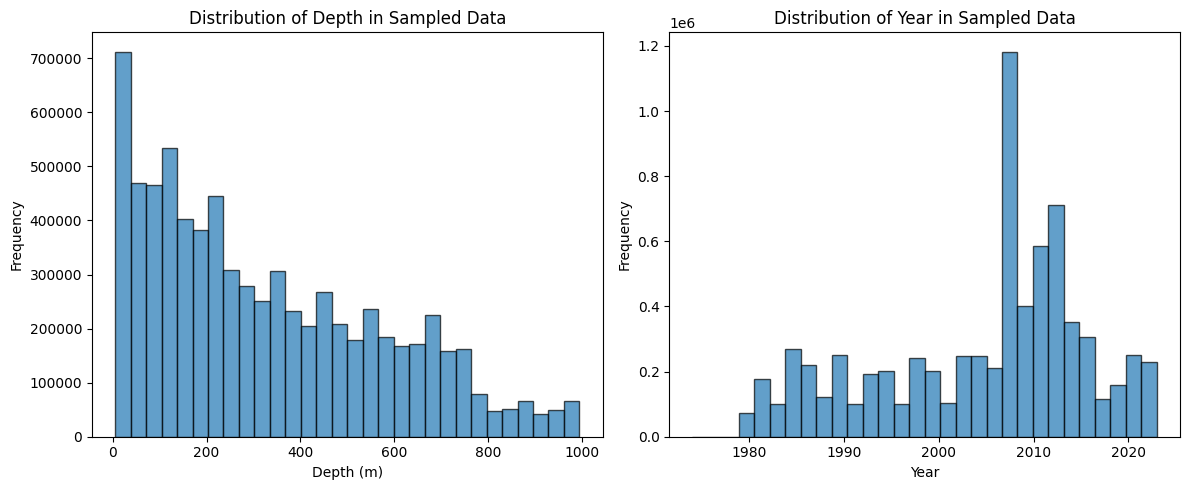

In [78]:
plt.figure(figsize=(12, 5))
plt.subplot(1, 2, 1)
plt.hist(df_sampled['Depth_[m]'], bins=30, edgecolor='black', alpha=0.7)
plt.xlabel('Depth (m)')
plt.ylabel('Frequency')
plt.title('Distribution of Depth in Sampled Data')
plt.subplot(1, 2, 2)
plt.hist(df_sampled['year'], bins=30, edgecolor='black', alpha=0.7)
plt.xlabel('Year')
plt.ylabel('Frequency')
plt.title('Distribution of Year in Sampled Data')
plt.tight_layout()
plt.show()

In [ ]:
plot_heatmap_npts(df_sampled, lon_step=2, lat_step=2)

# Method 28 - Polar stereographic projection, 95th percentile random sampling overflow bins

In [56]:
threshold = profileNo_vs_xy_bins(df_ST, n_x_bins=100, n_y_bins=100, show_threshold=True, threshold_quantile=0.95, projection='npstere')

In [57]:
print(threshold)

10671


In [58]:
def sample_cap_bins_xy(df, thresh, n_x_bins, n_y_bins):
    # Define projection and reproject lat/lon to x/y
    lat_min = df['Latitude_[deg_N]'].min()
    m = Basemap(projection='npstere', boundinglat=lat_min, lon_0=0, resolution='l')
    lon_vals = df['Longitude_[deg_E]'].values
    lat_vals = df['Latitude_[deg_N]'].values
    x_vals, y_vals = m(lon_vals, lat_vals)

    # Define XY bin edges in projected space
    x_bins = np.linspace(x_vals.min(), x_vals.max(), n_x_bins + 1)
    y_bins = np.linspace(y_vals.min(), y_vals.max(), n_y_bins + 1)

    # Assign points to bins and clip edge cases
    x_idx = np.clip(np.digitize(x_vals, x_bins) - 1, 0, n_x_bins - 1)
    y_idx = np.clip(np.digitize(y_vals, y_bins) - 1, 0, n_y_bins - 1)

    # Build a dict mapping (xi, yi) -> list of original df indices
    # This is the single source of truth for bin membership
    from collections import defaultdict
    bin_members = defaultdict(list)
    for i in range(len(x_vals)):
        bin_members[(x_idx[i], y_idx[i])].append(i)

    # Sample each bin: cap at thresh if over, keep all if under
    sampled_indices = []
    for (xi, yi), members in bin_members.items():
        if len(members) > thresh:
            sampled_indices.extend(
                np.random.choice(members, size=thresh, replace=False)
            )
        else:
            sampled_indices.extend(members)

    df_sampled = df.iloc[sampled_indices].copy()
    return df_sampled

In [60]:
df_sampled = sample_cap_bins_xy(df_ST, thresh=threshold, n_x_bins=100, n_y_bins=100)

In [61]:
_ = profileNo_vs_xy_bins(df_sampled, n_x_bins=100, n_y_bins=100, show_threshold=False, threshold_quantile=0.95, projection='npstere')

# Four clusters to compare methods

In [62]:
# Four clusters for comparison of methods
n_clusters = 4

In [63]:
gmm = GaussianMixture(
    n_components=n_clusters,          # number of clusters
    covariance_type='full',  # full cov matrix has more flexibility
    random_state=seed)

labels = gmm.fit_predict(df_sampled[features])

In [64]:
df_sampled['gmm_label_4'] = labels

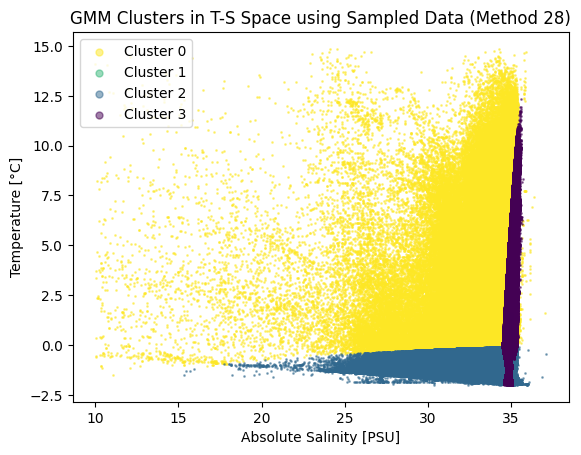

In [65]:
plt.figure()

# Discrete Viridis colours full range (reversed)
colors = plt.cm.viridis_r(np.linspace(0, 1, n_clusters))

for i in range(n_clusters):
    mask = df_sampled['gmm_label_4'] == i
    plt.scatter(
        df_sampled.loc[mask, 'Absolute_Salinity_[PSU]'],
        df_sampled.loc[mask, 'Conservative_Temperature_[deg_C]'],
        s=1,
        alpha=0.5,
        color=colors[i],
        label=f'Cluster {i}')

plt.xlabel("Absolute Salinity [PSU]")
plt.ylabel("Temperature [°C]")
plt.title("GMM Clusters in T-S Space using Sampled Data (Method 28)")
plt.legend(loc='upper left', markerscale=5)
plt.show()

## BIC score

In [66]:
# Define random seed for reproducibility
seed = 22
random.seed(seed)

In [67]:
# Do BIC and AIC calculation for different number of clusters
bic_scores = []
n_components_range = range(1, 12)
for n_components in n_components_range:
    gmm = GaussianMixture(n_components=n_components, covariance_type='full', random_state=seed) # full cov matrix has more flexibility
    gmm.fit(df_sampled[features])
    bic_scores.append(gmm.bic(df_sampled[features]))

Text(0.5, 1.0, 'BIC Scores for GMM with Different Number of Components')

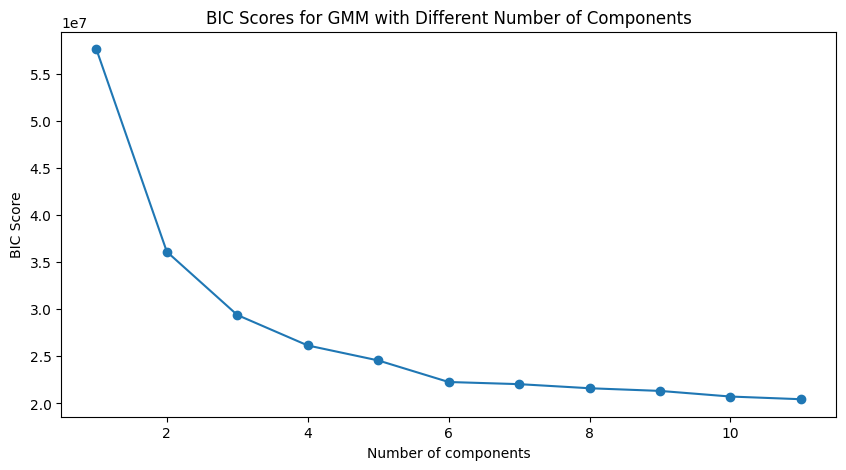

In [68]:
plt.figure(figsize=(10,5))
plt.plot(n_components_range, bic_scores, label='BIC', marker='o')
plt.xlabel('Number of components')
plt.ylabel('BIC Score')
plt.title('BIC Scores for GMM with Different Number of Components')

In [74]:
# Choice of optimal number of clusters based on BIC
optimal_n_components = 6

In [75]:
gmm = GaussianMixture(
    n_components=optimal_n_components,          # number of clusters
    covariance_type='full',  # full cov matrix has more flexibility
    random_state=seed)

labels = gmm.fit_predict(df_sampled[features])

In [76]:
df_sampled['gmm_label'] = labels

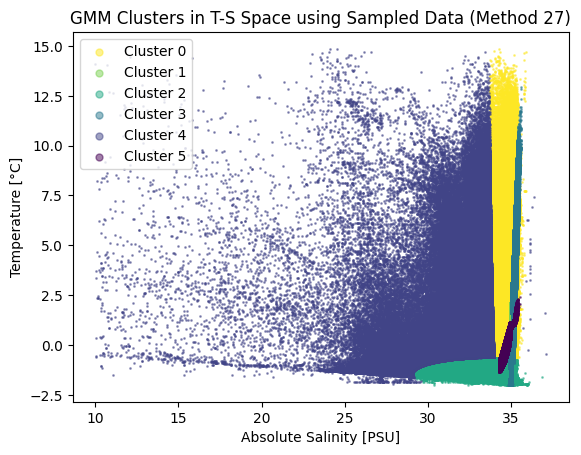

In [77]:
plt.figure()

# Discrete Viridis colours full range (reversed)
colors = plt.cm.viridis_r(np.linspace(0, 1, optimal_n_components))

for i in range(optimal_n_components):
    mask = df_sampled['gmm_label'] == i
    plt.scatter(
        df_sampled.loc[mask, 'Absolute_Salinity_[PSU]'],
        df_sampled.loc[mask, 'Conservative_Temperature_[deg_C]'],
        s=1,
        alpha=0.5,
        color=colors[i],
        label=f'Cluster {i}')

plt.xlabel("Absolute Salinity [PSU]")
plt.ylabel("Temperature [°C]")
plt.title("GMM Clusters in T-S Space using Sampled Data (Method 27)")
plt.legend(loc='upper left', markerscale=5)
plt.show()

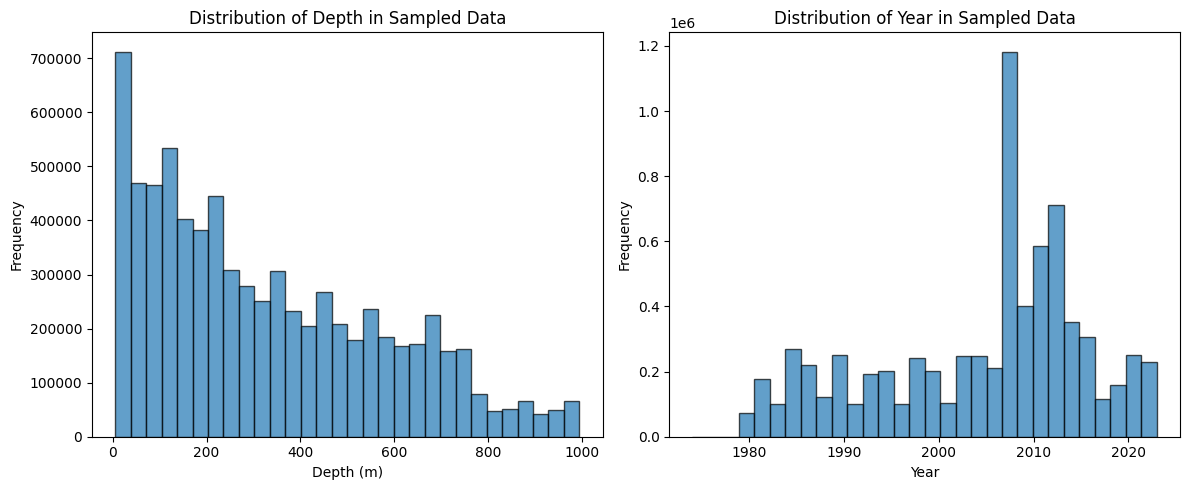

In [73]:
plt.figure(figsize=(12, 5))
plt.subplot(1, 2, 1)
plt.hist(df_sampled['Depth_[m]'], bins=30, edgecolor='black', alpha=0.7) 
plt.xlabel('Depth (m)')
plt.ylabel('Frequency')
plt.title('Distribution of Depth in Sampled Data')
plt.subplot(1, 2, 2)
plt.hist(df_sampled['year'], bins=30, edgecolor='black', alpha=0.7)    
plt.xlabel('Year')
plt.ylabel('Frequency')
plt.title('Distribution of Year in Sampled Data')
plt.tight_layout()
plt.show()

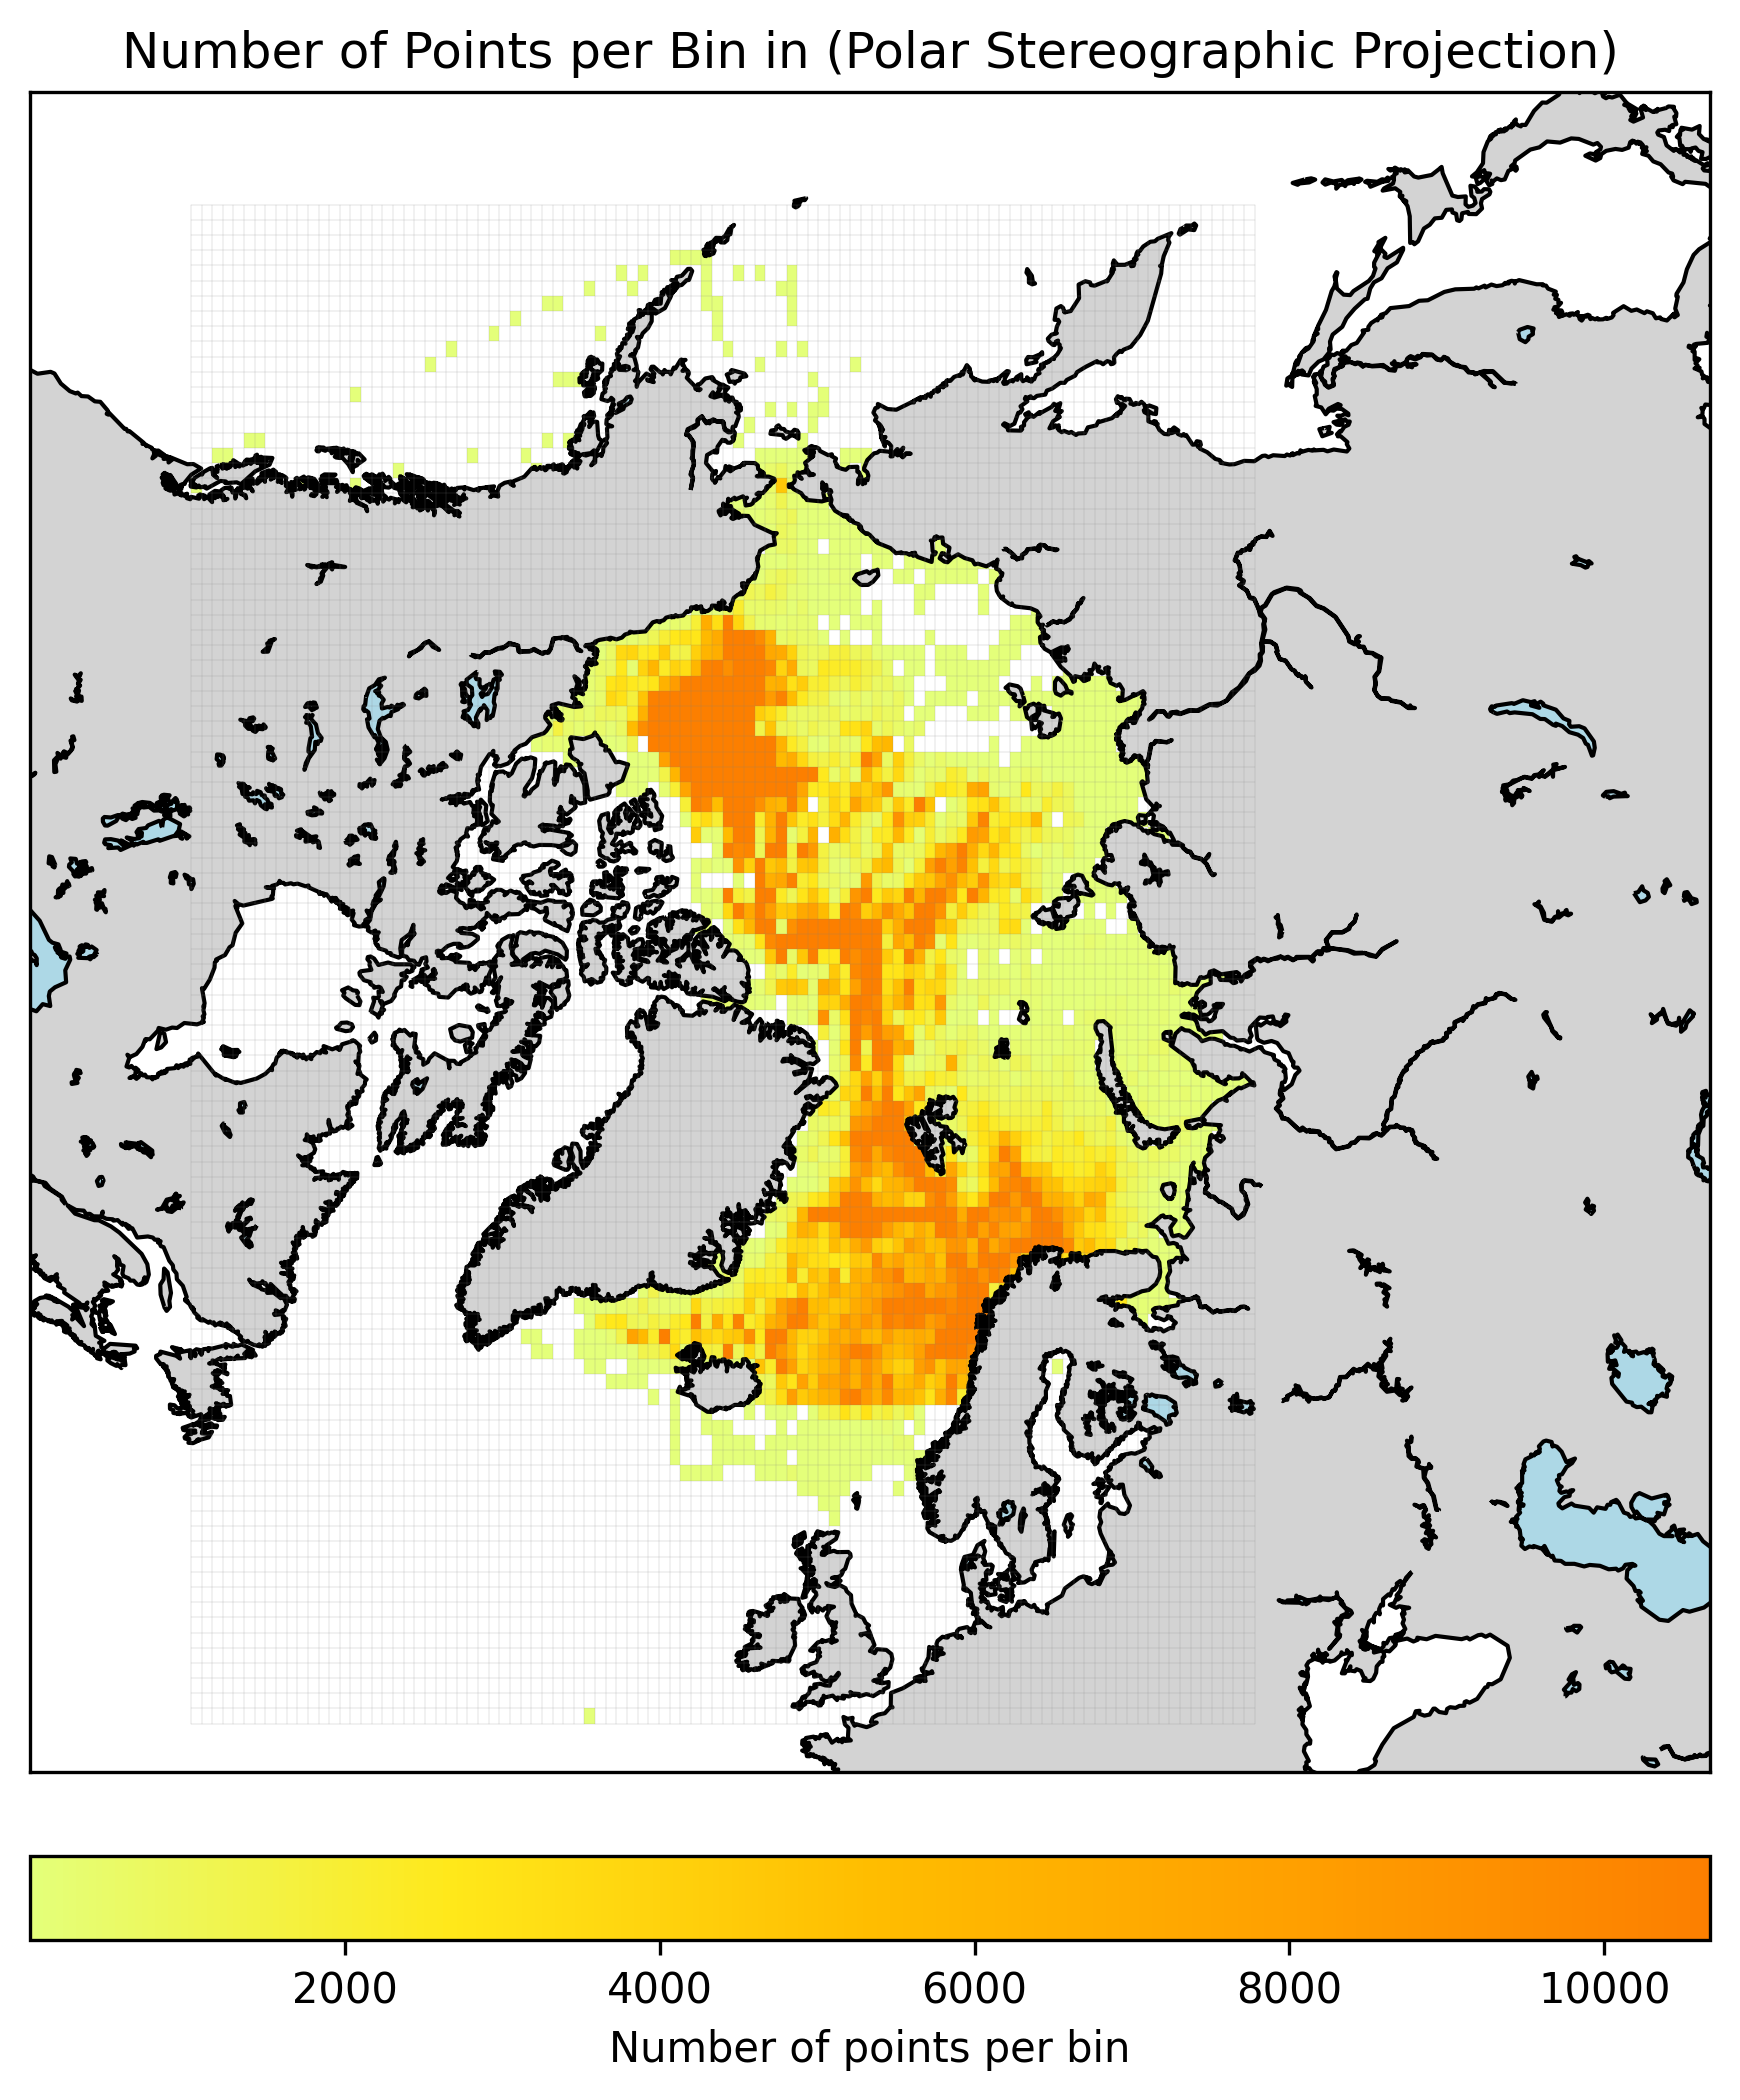

In [72]:
plot_heatmap_npts_xy(df_sampled, n_x_bins=100, n_y_bins=100, projection='npstere', projection_name='Polar Stereographic')